#### Biggest predictor of CO2 output

**What is the biggest predictor of a large CO2 output per capita of a country?**

To determine this you may want to consider things like GDP per capita, diets, number of cars per capita, various energy source, mobility and other factors.

Your answer can also be a specific combination of certain factors. Anyway, remember to include the explanations in your report.

In [32]:
from matplotlib.dates import YearLocator, DateFormatter
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [ ]:
# Import the original Kaya Identity CO2 data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/kaya-identity-co2.csv')
df_original_data = pd.read_csv('../data/kaya-identity-co2.csv')

In [28]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17064 entries, 0 to 17063
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Entity                           17064 non-null  str    
 1   Code                             15810 non-null  str    
 2   Year                             17064 non-null  int64  
 3   CO₂ emissions                    14350 non-null  float64
 4   Energy intensity (Energy / GDP)  7882 non-null   float64
 5   GDP per capita                   9671 non-null   float64
 6   Population                       15412 non-null  float64
 7   Carbon intensity (CO₂ / energy)  10511 non-null  float64
 8   Carbon intensity (CO₂ / $)       10122 non-null  float64
 9   GDP per capita (Annotations)     13 non-null     str    
dtypes: float64(6), int64(1), str(3)
memory usage: 1.3 MB


In [ ]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  1254
Missing values in column Year:  0
Missing values in column CO₂ emissions:  2714
Missing values in column Energy intensity (Energy / GDP):  9182
Missing values in column GDP per capita:  7393
Missing values in column Population:  1652
Missing values in column Carbon intensity (CO₂ / energy):  6553
Missing values in column Carbon intensity (CO₂ / $):  6942
Missing values in column GDP per capita (Annotations):  17051
Total number of NaN values in the DataFrame: 52741


In [ ]:
df_co2_kaya = df_original_data.copy()

# Drop unnecessary columns
df_co2_kaya.drop(columns=['Code', 'Carbon intensity (CO₂ / $)', 'GDP per capita (Annotations)'], inplace=True)

# Rename columns
df_co2_kaya.rename(columns={'Energy intensity (Energy / GDP)': 'Energy intensity',
                             'Carbon intensity (CO₂ / energy)': 'Carbon intensity'}, inplace=True)

In [29]:
df_co2_kaya.head()

,Entity,Year,CO₂ emissions,Energy intensity,GDP per capita,Population,Carbon intensity
0,Afghanistan,1965,1006917.0,NaN,1290.0,10036003.0,NaN
1,Afghanistan,1966,1091159.0,NaN,1272.0,10266397.0,NaN
2,Afghanistan,1967,1281865.0,NaN,1277.0,10505961.0,NaN
3,Afghanistan,1968,1223391.0,NaN,1290.0,10756924.0,NaN
4,Afghanistan,1969,941232.0,NaN,1278.0,11017417.0,NaN


Correlation with CO₂ emissions:
Energy intensity    0.029834
GDP per capita      0.076112
Population          0.930630
Carbon intensity    0.004130
Name: CO₂ emissions, dtype: float64


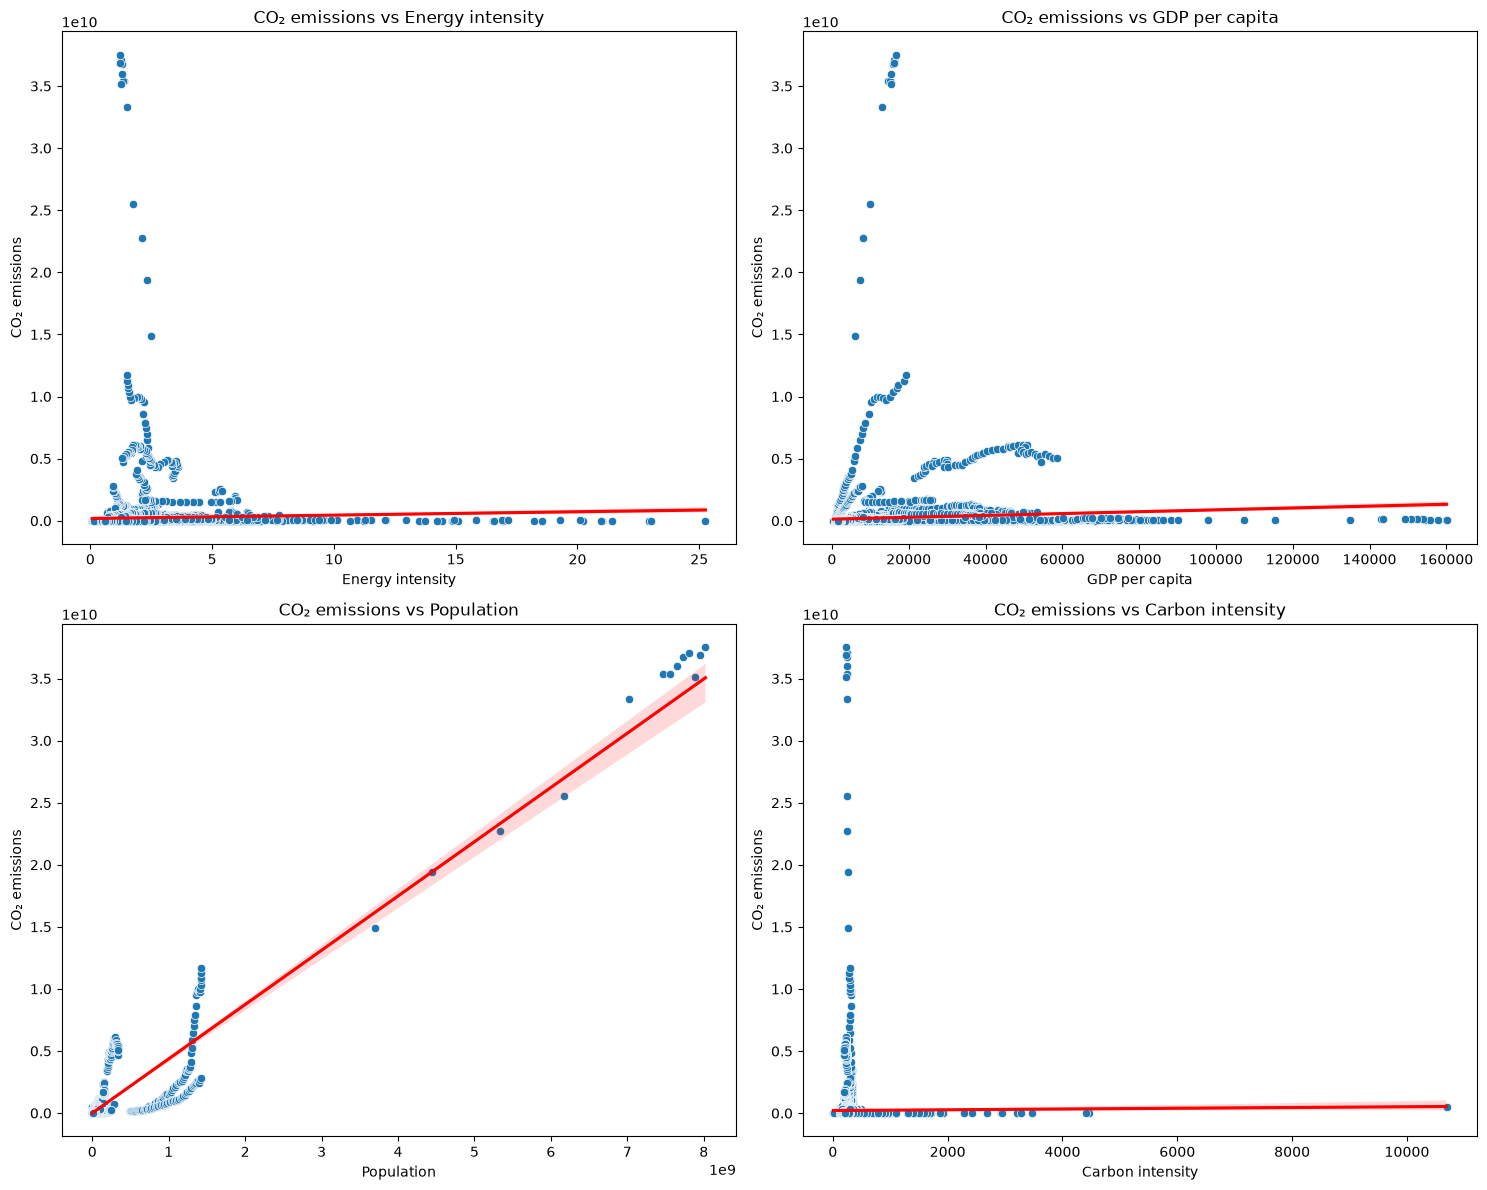

In [33]:
# Select the relevant columns for correlation analysis
correlation_columns = ['CO₂ emissions', 'Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']
df_corr = df_co2_kaya[correlation_columns].dropna()

# Calculate the correlation matrix
correlation_matrix = df_corr.corr()

# Extract correlations with 'CO₂ emissions'
co2_correlations = correlation_matrix['CO₂ emissions'].drop('CO₂ emissions')

print("Correlation with CO₂ emissions:")
print(co2_correlations)

# Plotting the correlations

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

plot_vars = ['Energy intensity', 'GDP per capita', 'Population', 'Carbon intensity']

for i, var in enumerate(plot_vars):
    sns.scatterplot(data=df_corr, x=var, y='CO₂ emissions', ax=axes[i])
    axes[i].set_title(f'CO₂ emissions vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('CO₂ emissions')
    # Optionally add a regression line
    sns.regplot(data=df_corr, x=var, y='CO₂ emissions', ax=axes[i], scatter=False, color='red')

plt.tight_layout()
plt.show()

In [30]:
df_corr.info()

<class 'pandas.DataFrame'>
Index: 7770 entries, 15 to 17061
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CO₂ emissions     7770 non-null   float64
 1   Energy intensity  7770 non-null   float64
 2   GDP per capita    7770 non-null   float64
 3   Population        7770 non-null   float64
 4   Carbon intensity  7770 non-null   float64
dtypes: float64(5)
memory usage: 364.2 KB
